In [2]:
import pandas as pd

# Load the financial news dataset
# Replace 'your_file_name.csv' with the actual name of the file in data/raw
df = pd.read_csv('../data/raw/raw_analyst_ratings.csv')

# Display the first 5 rows to see what we have
df.head()

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


In [3]:
df['headline_len'] = df['headline'].str.len()
print(df['headline_len'].describe())

count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_len, dtype: float64


In [4]:
active_publishers = df['publisher'].value_counts()
print(active_publishers.head(10))

publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64


<Axes: title={'center': 'News Volume Over Time'}, xlabel='date'>

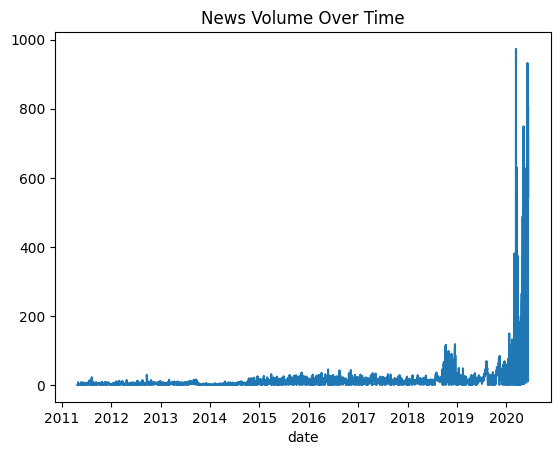

In [5]:
# Ensure date is in the right format
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['date'].dt.date.value_counts().sort_index().plot(title='News Volume Over Time')

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Initialize the Vectorizer
# 'stop_words' removes common words like 'the', 'is', 'and'
tfidf = TfidfVectorizer(stop_words='english', max_features=20)

# 2. Fit and transform your headlines
# Ensure 'df' is loaded with your 'raw_analyst_rating.csv'
tfidf_matrix = tfidf.fit_transform(df['headline'].dropna())

# 3. Get the top keywords
feature_names = tfidf.get_feature_names_out()
print("Significant Keywords Found:")
print(feature_names)

Significant Keywords Found:
['announces' 'benzinga' 'buy' 'downgrades' 'earnings' 'eps' 'est' 'market'
 'mid' 'price' 'pt' 'raises' 'reports' 'sales' 'shares' 'stocks' 'trading'
 'update' 'vs' 'week']


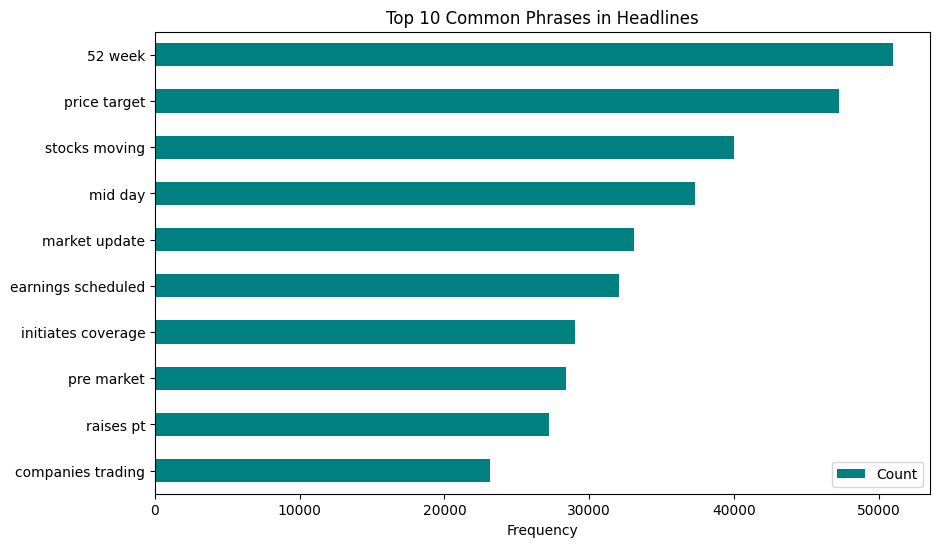

In [7]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
import matplotlib.pyplot as plt

# 1. Identify common phrases (Bigrams) using CountVectorizer
# This helps find themes like "price target" or "earnings beat" [cite: 113]
cv = CountVectorizer(stop_words='english', ngram_range=(2, 2), max_features=10)
bigram_matrix = cv.fit_transform(df['headline'].dropna())

# Create a DataFrame for the phrases
phrases_df = pd.DataFrame(bigram_matrix.sum(axis=0).T, 
                          index=cv.get_feature_names_out(), 
                          columns=['Count']).sort_values('Count', ascending=False)

# 2. Visualize the results (Insightful Visualization #1) [cite: 128]
phrases_df.head(10).plot(kind='barh', color='teal', figsize=(10, 6))
plt.title('Top 10 Common Phrases in Headlines')
plt.xlabel('Frequency')
plt.gca().invert_yaxis()
plt.show()

In [10]:
from sklearn.feature_extraction.text import CountVectorizer

# Look for 2-word phrases (bigrams)
cv = CountVectorizer(stop_words='english', ngram_range=(2, 2), max_features=10)
bigram_matrix = cv.fit_transform(df['headline'].dropna())

# Convert to a DataFrame for easy viewing
phrases_df = pd.DataFrame(bigram_matrix.sum(axis=0).T, 
                          index=cv.get_feature_names_out(), 
                          columns=['Count']).sort_values('Count', ascending=False)

print("\nTop Common Phrases:")
print(phrases_df)


Top Common Phrases:
                    Count
52 week             51006
price target        47274
stocks moving       40044
mid day             37324
market update       33101
earnings scheduled  32055
initiates coverage  28993
pre market          28393
raises pt           27213
companies trading   23170


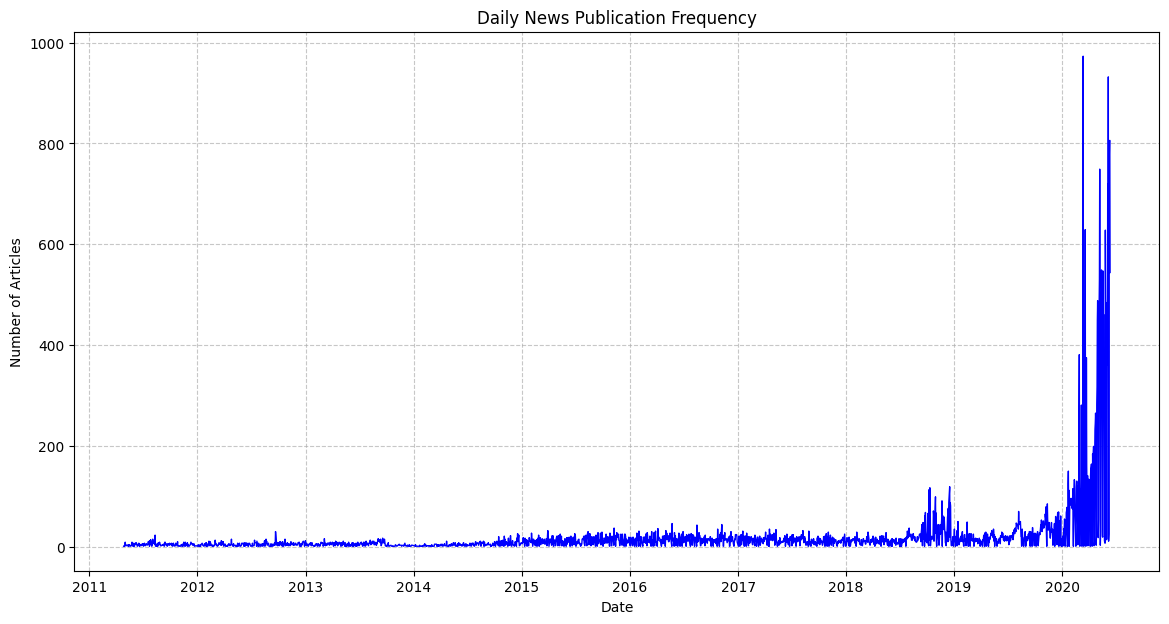

In [ ]:
import matplotlib.pyplot as plt

# Convert 'date' to datetime and handle errors [cite: 36]
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Drop any rows where the date couldn't be parsed
df = df.dropna(subset=['date'])

# Group by date and count articles
daily_counts = df.groupby(df['date'].dt.date).size()

# Visualization 1: Daily News Volume 
plt.figure(figsize=(14, 7))
daily_counts.plot(kind='line', color='blue', linewidth=1)
plt.title('Daily News Publication Frequency')
plt.xlabel('Date')
plt.ylabel('Number of Articles')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

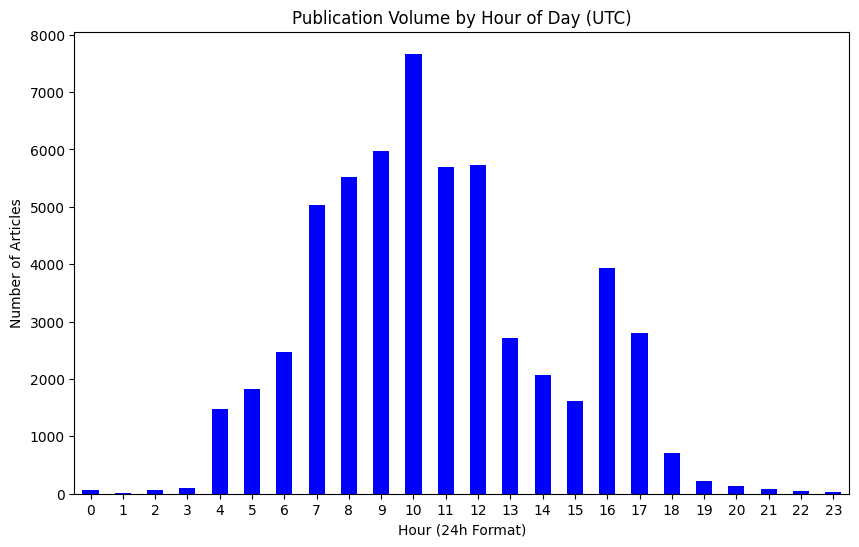

In [13]:
# Extract the hour from the timestamp
df['hour'] = df['date'].dt.hour

# Visualization 2: Hourly Publication Trends 
plt.figure(figsize=(10, 6))
df['hour'].value_counts().sort_index().plot(kind='bar', color='blue')
plt.title('Publication Volume by Hour of Day (UTC)')
plt.xlabel('Hour (24h Format)')
plt.ylabel('Number of Articles')
plt.xticks(rotation=0)
plt.show()

In [14]:
# Identify top 10 most active publishers
top_publishers = df['publisher'].value_counts().head(10)

# Characterize coverage: How many unique stocks does each top publisher mention?
publisher_coverage = df[df['publisher'].isin(top_publishers.index)].groupby('publisher')['stock'].nunique()

print("Top Publishers and their Unique Stock Coverage:")
print(publisher_coverage.sort_values(ascending=False))

Top Publishers and their Unique Stock Coverage:
publisher
Benzinga Newsdesk    3771
Lisa Levin           3646
Paul Quintaro        1242
Vick Meyer           1228
Benzinga Insights    1202
Charles Gross        1023
ETF Professor        1010
Benzinga Newsdesk     956
Benzinga_Newsdesk     913
Hal Lindon            844
Name: stock, dtype: int64


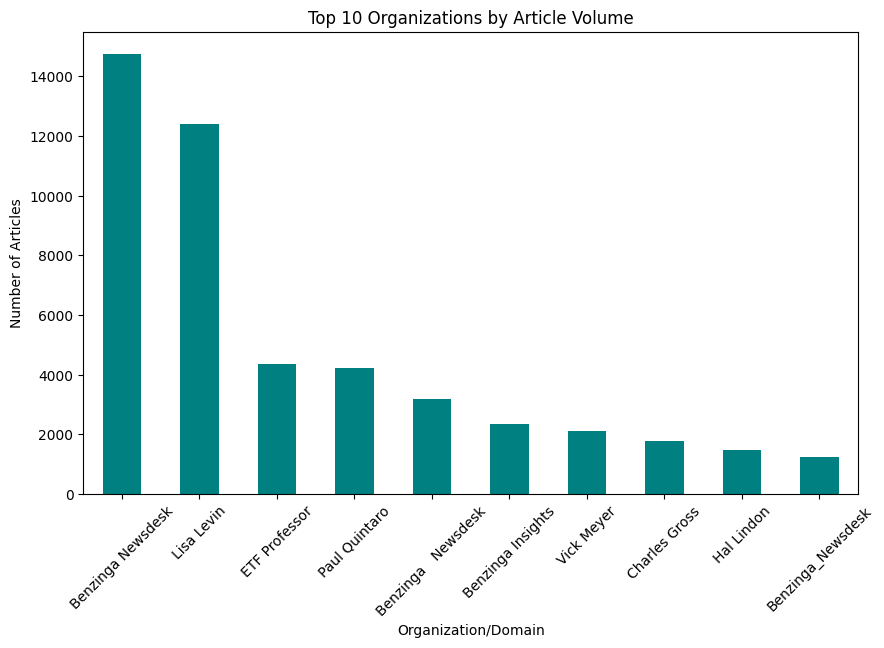

In [16]:
# Function to extract domain if it looks like an email
def extract_domain(publisher):
    if '@' in str(publisher):
        return str(publisher).split('@')[-1]
    return publisher

# Apply the function and analyze organizational patterns
df['organization'] = df['publisher'].apply(extract_domain)
org_counts = df['organization'].value_counts().head(10)

# Visualization 3: Organizational Contribution
plt.figure(figsize=(10, 6))
org_counts.plot(kind='bar', color='teal')
plt.title('Top 10 Organizations by Article Volume')
plt.xlabel('Organization/Domain')
plt.ylabel('Number of Articles')
plt.xticks(rotation=45)
plt.show()